# Навигация по DataFlash без GPS: хронология исследования

Цель: начать каждую проверочную часть полета в известной точке, дальше складывать только предсказанные по бортовым датчикам перемещения и сравнить полученную траекторию с реальной траекторией `POS/GPS`.

Ноутбук построен как журнал разработки: от проверки источников и простых baseline до последовательной модели, анализа накопленного дрейфа и sensor-only коррекции режимов. Он ничего не записывает в `HTML` или `Markdown`; результатом являются числа, таблицы и графики прямо в notebook.

Ключевое ограничение: в репозитории найден один исходный DataFlash-лог. Поэтому три fold ниже — это три последовательных тестовых отрезка одного полета, а не три независимых полета. Итоговые цифры оценивают перенос во времени внутри этого лога, но пока не доказывают перенос на другой полет.

In [1]:
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (11, 5), 'axes.spines.top': False, 'axes.spines.right': False})

cwd = Path.cwd().resolve()
ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'src').exists() and (p / 'derived').exists()), None)
if ROOT is None:
    raise RuntimeError('Запустите notebook из репозитория IMU_navigation')

DATA = ROOT / 'derived' / 'dataflash'
RAW = ROOT / 'artifacts'
print('Project root:', ROOT)

Project root: /home/user/Projects/For_stud/IMU_navigation


## 1. Источник данных и проверка числа полетов

`DataFlash` — формат бортового журнала ArduPilot. CSV здесь не другой эксперимент: таблицы `IMU`, `ATT`, `BARO`, `POS`, `GPS`, `RCOU`, `MOTB`, `BAT` извлечены из одного текстового DataFlash-лога и синхронизируются по `TimeUS`.

In [2]:
raw_logs = sorted(RAW.rglob('*.log'))
raw_bins = sorted(RAW.rglob('*.bin'))
inventory = pd.DataFrame({
    'kind': ['text DataFlash'] * len(raw_logs) + ['binary DataFlash'] * len(raw_bins),
    'file': [str(p.relative_to(ROOT)) for p in raw_logs + raw_bins],
    'size_MiB': [p.stat().st_size / 2**20 for p in raw_logs + raw_bins],
})
display(inventory)
print(f'Независимых текстовых DataFlash-логов: {len(raw_logs)}')

,kind,file,size_MiB
0,text DataFlash,artifacts/initial/2025-01-15 16-46-48.log,28.979971
1,binary DataFlash,artifacts/initial/2025-01-15 16-46-48.bin,13.447758


Независимых текстовых DataFlash-логов: 1


In [3]:
# Минимальный разбор сырого text DataFlash в памяти: FMT задает столбцы сообщений.
SELECTED = {'IMU', 'ATT', 'BARO', 'POS', 'GPS', 'RCOU', 'MOTB', 'BAT'}

def inspect_dataflash(path, selected=SELECTED):
    formats, counts = {}, Counter()
    with path.open(encoding='ascii', errors='replace') as f:
        for line in f:
            parts = [x.strip() for x in line.strip().split(',')]
            if not parts or not parts[0]:
                continue
            kind = parts[0]
            counts[kind] += 1
            if kind == 'FMT' and len(parts) >= 6:
                formats[parts[3]] = parts[5:]
    return formats, counts

formats, message_counts = inspect_dataflash(raw_logs[0])
raw_summary = pd.DataFrame([
    {'message': name, 'rows_in_raw_log': message_counts[name], 'columns': len(formats.get(name, [])),
     'csv_exists': (DATA / f'{name}.csv').exists()}
    for name in sorted(SELECTED)
])
display(raw_summary)

,message,rows_in_raw_log,columns,csv_exists
0,ATT,8784,8,True
1,BARO,8784,11,True
2,BAT,8783,12,True
3,GPS,4394,15,True
4,IMU,21958,15,True
5,MOTB,8779,7,True
6,POS,8779,6,True
7,RCOU,8779,15,True


## 2. Загрузка, очистка и реальная траектория

`POS` используется только как эталон и как целевая переменная при обучении. Во вход модели координаты, GPS-скорость и будущие координаты не попадают. Локальная система: east, north, up в метрах относительно первой записи `POS`.

In [4]:
tables = {name: pd.read_csv(DATA / f'{name}.csv') for name in sorted(SELECTED)}
quality = []
for name, frame in tables.items():
    t = pd.to_numeric(frame['TimeUS'], errors='coerce')
    quality.append({
        'table': name, 'rows': len(frame), 'columns': frame.shape[1],
        'duration_min': (t.max() - t.min()) / 60e6,
        'duplicate_TimeUS': int(t.duplicated().sum()),
        'missing_cells': int(frame.isna().sum().sum()),
    })
display(pd.DataFrame(quality).sort_values('table'))

,table,rows,columns,duration_min,duplicate_TimeUS,missing_cells
0,ATT,8784,8,14.654121,0,0
1,BARO,8784,11,14.654052,0,0
2,BAT,8783,12,14.645690,0,0
3,GPS,4394,15,14.653609,0,0
4,IMU,21958,15,14.654867,0,0
5,MOTB,8779,7,14.654106,0,0
6,POS,8779,6,14.654108,0,0
7,RCOU,8779,15,14.654103,0,0


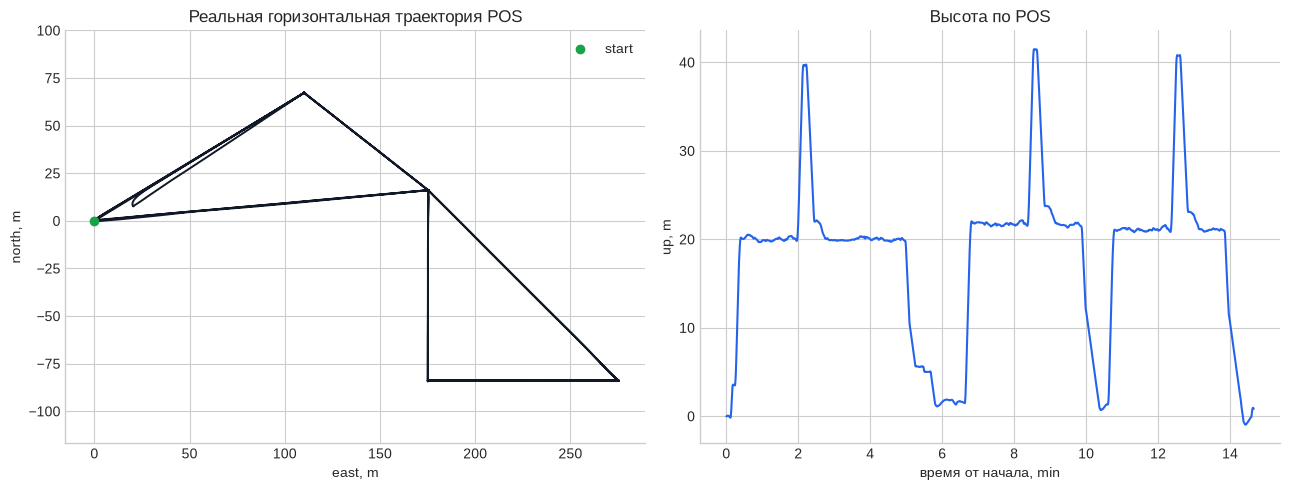

In [5]:
def gps_to_local(lat, lon, alt):
    lat = np.asarray(lat, float); lon = np.asarray(lon, float); alt = np.asarray(alt, float)
    lat0, lon0, alt0 = lat[0], lon[0], alt[0]
    r = 6_371_000.0
    north = np.deg2rad(lat - lat0) * r
    east = np.deg2rad(lon - lon0) * r * np.cos(np.deg2rad(lat0))
    return np.column_stack([east, north, alt - alt0])

pos_df = tables['POS'].dropna(subset=['TimeUS', 'Lat', 'Lng', 'Alt']).sort_values('TimeUS')
pos_times = pos_df.TimeUS.to_numpy(float)
positions = gps_to_local(pos_df.Lat, pos_df.Lng, pos_df.Alt)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(positions[:, 0], positions[:, 1], color='#111827', lw=1.4)
ax[0].scatter(positions[0, 0], positions[0, 1], color='#16a34a', label='start', zorder=3)
ax[0].set(xlabel='east, m', ylabel='north, m', title='Реальная горизонтальная траектория POS')
ax[0].axis('equal'); ax[0].legend()
time_min = (pos_times - pos_times[0]) / 60e6
ax[1].plot(time_min, positions[:, 2], color='#2563eb')
ax[1].set(xlabel='время от начала, min', ylabel='up, m', title='Высота по POS')
plt.tight_layout(); plt.show()

## 3. Что видят датчики

Проверяем IMU, ориентацию, барометр и моторы на общей временной шкале. Optical flow в этом DataFlash-наборе отсутствует, поэтому смешивать его с моделью этого полета нельзя.

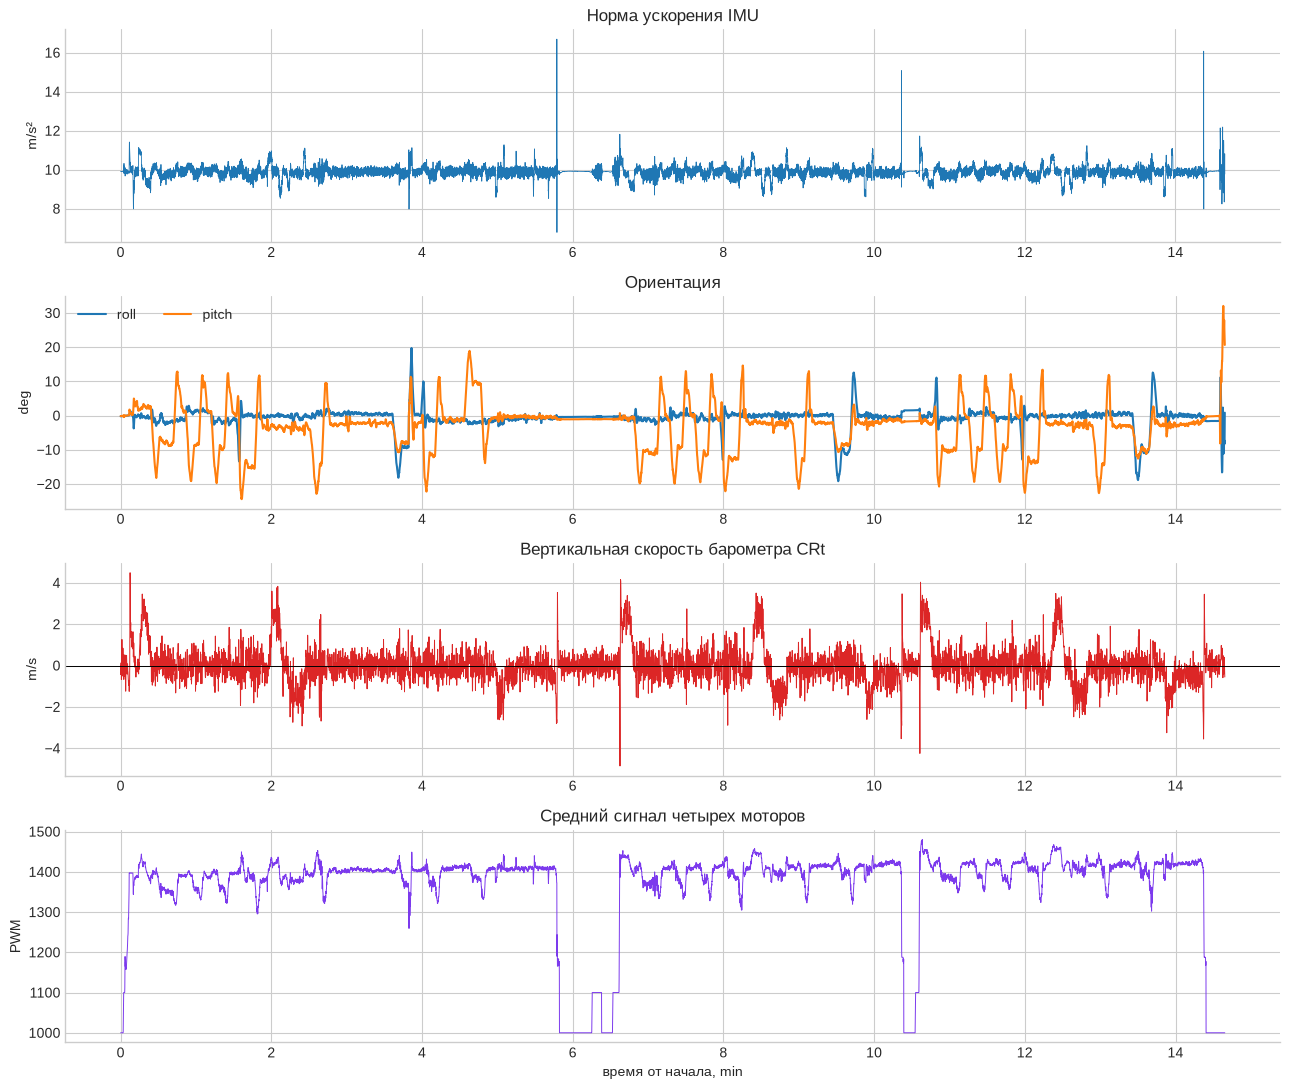

In [6]:
imu, att, baro = tables['IMU'], tables['ATT'], tables['BARO']
rcou = tables['RCOU']
motor_cols = [c for c in ['C1', 'C2', 'C3', 'C4'] if c in rcou]
motor_mean = rcou[motor_cols].mean(axis=1)

fig, ax = plt.subplots(4, 1, figsize=(13, 11), sharex=False)
ti = (imu.TimeUS - pos_times[0]) / 60e6
ax[0].plot(ti, np.linalg.norm(imu[['AccX','AccY','AccZ']], axis=1), lw=.6)
ax[0].set(ylabel='m/s²', title='Норма ускорения IMU')
ta = (att.TimeUS - pos_times[0]) / 60e6
ax[1].plot(ta, att.Roll, label='roll'); ax[1].plot(ta, att.Pitch, label='pitch'); ax[1].legend(ncol=2)
ax[1].set(ylabel='deg', title='Ориентация')
tb = (baro.TimeUS - pos_times[0]) / 60e6
ax[2].plot(tb, baro.CRt, color='#dc2626', lw=.7); ax[2].axhline(0, color='black', lw=.7)
ax[2].set(ylabel='m/s', title='Вертикальная скорость барометра CRt')
tr = (rcou.TimeUS - pos_times[0]) / 60e6
ax[3].plot(tr, motor_mean, color='#7c3aed', lw=.7)
ax[3].set(xlabel='время от начала, min', ylabel='PWM', title='Средний сигнал четырех моторов')
plt.tight_layout(); plt.show()

## 4. Формирование последовательностей

Для каждой точки `POS` берем 20 синхронизированных срезов датчиков за предыдущие 5 секунд. Цель — перемещение `[dE, dN, dU]` через следующие 5 секунд. Такой горизонт дает разреженный dead-reckoning rollout и не является интегрированием IMU на полной частоте.

In [7]:
DROP = {'I', 'Inst', 'Health', 'H', 'SH', 'FailFlags'}
FEATURE_TABLES = ['IMU', 'ATT', 'BARO']

@dataclass
class Series:
    name: str
    times: np.ndarray
    values: np.ndarray
    names: list

def make_series(name):
    df = tables[name].sort_values('TimeUS').copy()
    cols = [c for c in df.columns if c != 'TimeUS' and c not in DROP]
    numeric = df[['TimeUS', *cols]].apply(pd.to_numeric, errors='coerce').dropna()
    values = numeric[cols].to_numpy(float)
    names = [f'{name}.{c}' for c in cols]
    extra, extra_names = [], []
    if name == 'IMU':
        for label, cs in [('gyro_norm',['GyrX','GyrY','GyrZ']), ('acc_norm',['AccX','AccY','AccZ'])]:
            extra.append(np.linalg.norm(numeric[cs].to_numpy(float), axis=1)[:, None]); extra_names.append(f'{name}.{label}')
    if name == 'ATT':
        yaw = np.deg2rad(numeric.Yaw.to_numpy(float))
        extra += [np.sin(yaw)[:,None], np.cos(yaw)[:,None]]; extra_names += ['ATT.sin_yaw','ATT.cos_yaw']
    if extra:
        values = np.hstack([values, *extra]); names += extra_names
    return Series(name, numeric.TimeUS.to_numpy(float), values, names)

series = [make_series(name) for name in FEATURE_TABLES]

def sample_sequence(series_list, time_us, lookback_us=5e6, sequence_len=20):
    parts = []
    for offset in np.linspace(-lookback_us, 0, sequence_len):
        for s in series_list:
            idx = np.searchsorted(s.times, time_us + offset, side='right') - 1
            if idx < 0: return None
            parts.append(s.values[idx])
    return np.concatenate(parts)

def build_dataset(horizon_us=5e6, lookback_us=5e6, sequence_len=20):
    x, y, now, future, p0, p1 = [], [], [], [], [], []
    future_idx = np.searchsorted(pos_times, pos_times + horizon_us, side='left')
    for i, j in enumerate(future_idx):
        if j >= len(pos_times): continue
        features = sample_sequence(series, pos_times[i], lookback_us, sequence_len)
        if features is None: continue
        x.append(features); y.append(positions[j] - positions[i])
        now.append(pos_times[i]); future.append(pos_times[j]); p0.append(positions[i]); p1.append(positions[j])
    return {k: np.asarray(v) for k, v in dict(x=x,y=y,time=now,future_time=future,pos=p0,future_pos=p1).items()}

ds = build_dataset()
print(f"windows={len(ds['x']):,}, features={ds['x'].shape[1]}, target={ds['y'].shape[1]}")

windows=8,688, features=640, target=3


## 5. Временная проверка и смысл трех fold

Полет делится на 6 последовательных блоков. В каждом fold обучение использует только прошлое, затем один блок служит validation, следующий — test. Поэтому тестовые траектории нельзя склеивать или накладывать как один непрерывный полет: каждая начинается с собственной истинной стартовой точки.

,fold,train,val,test,train_blocks,val_block,test_block
0,1,2896,1448,1448,0-1,2,3
1,2,4344,1448,1448,0-2,3,4
2,3,5792,1448,1448,0-3,4,5


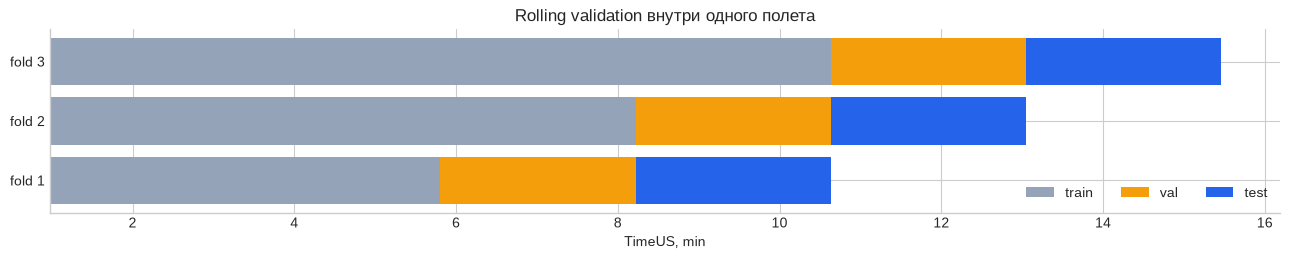

In [8]:
blocks = [np.asarray(b, int) for b in np.array_split(np.arange(len(ds['x'])), 6)]
folds = []
for fold_id, val_block in enumerate(range(2, 5), 1):
    folds.append(dict(
        fold=fold_id,
        train=np.concatenate(blocks[:val_block]),
        val=blocks[val_block],
        test=blocks[val_block + 1],
        train_blocks=f'0-{val_block-1}', val_block=val_block, test_block=val_block+1,
    ))

display(pd.DataFrame([{k: v if not isinstance(v, np.ndarray) else len(v) for k,v in f.items()} for f in folds]))

fig, ax = plt.subplots(figsize=(13, 2.7))
colors = {'train':'#94a3b8', 'val':'#f59e0b', 'test':'#2563eb'}
for row, f in enumerate(folds):
    for role in ['train','val','test']:
        idx = f[role]
        x0, x1 = ds['time'][idx[0]]/60e6, ds['time'][idx[-1]]/60e6
        ax.barh(row, x1-x0, left=x0, color=colors[role], label=role if row == 0 else None)
ax.set(yticks=range(3), yticklabels=[f'fold {i}' for i in range(1,4)], xlabel='TimeUS, min', title='Rolling validation внутри одного полета')
ax.legend(ncol=3); plt.tight_layout(); plt.show()

## 6. Baseline и sequence ridge

Сравниваются: нулевое перемещение, среднее перемещение обучающей части и ridge по последовательности датчиков. Масштабирование признаков вычисляется только по train. `alpha=100` выбран предыдущим validation sweep и далее фиксирован, чтобы не подгонять test каждого fold.

In [9]:
def fit_ridge(x, y, alpha):
    xm, xs = x.mean(0), x.std(0); xs[xs < 1e-9] = 1
    ym = y.mean(0); xz = (x-xm)/xs
    w = np.linalg.solve(xz.T @ xz + alpha*np.eye(x.shape[1]), xz.T @ (y-ym))
    return w, xm, xs, ym

def predict_ridge(x, model):
    w, xm, xs, ym = model
    return (x-xm)/xs @ w + ym

def metrics(y, pred):
    e = pred-y; d = np.linalg.norm(e, axis=1)
    return {'MAE east':np.mean(abs(e[:,0])), 'MAE north':np.mean(abs(e[:,1])), 'MAE up':np.mean(abs(e[:,2])),
            'MAE 3D':d.mean(), 'RMSE 3D':np.sqrt(np.mean(d*d)), 'P95 3D':np.percentile(d,95)}

predictions = []
metric_rows = []
for f in folds:
    tr, va, te = f['train'], f['val'], f['test']
    model = fit_ridge(ds['x'][tr], ds['y'][tr], 100)
    ridge_val = predict_ridge(ds['x'][va], model)
    ridge_test = predict_ridge(ds['x'][te], model)
    bias = np.mean(ds['y'][va] - ridge_val, axis=0)
    candidates = [0, .25, .5, .75, 1]
    shrink = min(candidates, key=lambda s: metrics(ds['y'][va], ridge_val+s*bias)['MAE 3D'])
    models = {
        'zero': np.zeros_like(ds['y'][te]),
        'train_mean': np.repeat(ds['y'][tr].mean(0)[None], len(te), axis=0),
        'sequence_ridge': ridge_test,
        'bias_tuned': ridge_test + shrink*bias,
    }
    for name, pred in models.items():
        metric_rows.append({'fold':f['fold'], 'model':name, **metrics(ds['y'][te], pred)})
    predictions.append({'fold':f, 'test_pred':models['bias_tuned'], 'val_pred':ridge_val+shrink*bias,
                        'shrink':shrink, 'bias':bias})

metric_df = pd.DataFrame(metric_rows)
display(metric_df.round(3))
display(metric_df.groupby('model').agg({'MAE 3D':'mean','RMSE 3D':'mean','P95 3D':'mean'}).round(3))
print('validation-selected bias shrink by fold:', [p['shrink'] for p in predictions])

,fold,model,MAE east,MAE north,MAE up,MAE 3D,RMSE 3D,P95 3D
0,1,zero,13.121,10.306,1.469,19.807,27.467,49.708
1,1,train_mean,13.122,10.308,1.636,19.865,27.470,49.711
2,1,sequence_ridge,9.867,8.213,2.392,14.458,16.565,29.790
3,1,bias_tuned,9.744,7.386,1.523,13.680,16.663,32.052
4,2,zero,12.647,7.111,1.510,18.813,27.076,49.881
5,2,train_mean,13.415,7.143,1.594,18.862,26.660,49.673
6,2,sequence_ridge,12.324,7.537,1.208,15.833,17.684,30.748
7,2,bias_tuned,13.054,6.995,1.152,16.331,18.032,30.139
8,3,zero,6.576,4.596,2.229,10.133,17.793,47.657
9,3,train_mean,6.574,4.596,2.327,10.188,17.800,47.655


,MAE 3D,RMSE 3D,P95 3D
model,,,
bias_tuned,13.990,16.273,29.204
sequence_ridge,15.316,17.299,30.686
train_mean,16.305,23.977,49.013
zero,16.251,24.112,49.082


validation-selected bias shrink by fold: [1, 0.5, 1]


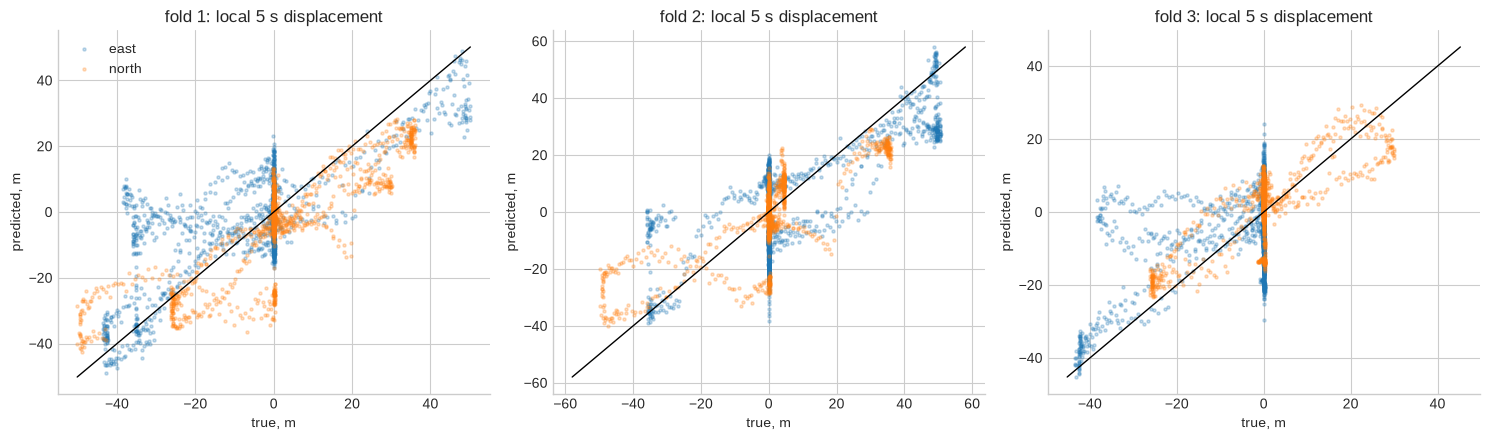

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for p, ax in zip(predictions, axes):
    idx, pred = p['fold']['test'], p['test_pred']
    ax.scatter(ds['y'][idx,0], pred[:,0], s=5, alpha=.25, label='east')
    ax.scatter(ds['y'][idx,1], pred[:,1], s=5, alpha=.25, label='north')
    lim = np.nanmax(np.abs(np.r_[ds['y'][idx,:2].ravel(), pred[:,:2].ravel()]))
    ax.plot([-lim,lim],[-lim,lim], color='black', lw=1)
    ax.set(title=f"fold {p['fold']['fold']}: local 5 s displacement", xlabel='true, m', ylabel='predicted, m')
axes[0].legend(); plt.tight_layout(); plt.show()

## 7. Dead-reckoning rollout

Теперь GPS/POS используется только для стартовой точки и последующей оценки. Из каждого test-блока выбираются неперекрывающиеся 5-секундные окна; предсказанные перемещения последовательно суммируются. Каждый fold строится отдельно.

In [11]:
def non_overlapping(indices):
    selected, next_time = [], -np.inf
    for local_i, data_i in enumerate(indices):
        if ds['time'][data_i] + 1e-3 < next_time: continue
        selected.append((local_i, data_i)); next_time = ds['future_time'][data_i]
    return selected

def rollout(indices, pred, gate=None):
    selected = non_overlapping(indices)
    current = ds['pos'][selected[0][1]].copy()
    rows = []
    for step, (pred_i, data_i) in enumerate(selected, 1):
        delta = pred[pred_i].copy()
        scale, state = (1.0, 'normal') if gate is None else gate(data_i, delta)
        delta[:2] *= scale
        current += delta
        true = ds['future_pos'][data_i]
        rows.append({'step':step, 'data_i':data_i, 'time':ds['future_time'][data_i], 'state':state, 'xy_scale':scale,
                     'true_e':true[0], 'true_n':true[1], 'true_u':true[2],
                     'pred_e':current[0], 'pred_n':current[1], 'pred_u':current[2],
                     'err_h':np.linalg.norm(current[:2]-true[:2]), 'err_3d':np.linalg.norm(current-true)})
    return pd.DataFrame(rows)

rollouts = []
for p in predictions:
    ro = rollout(p['fold']['test'], p['test_pred']); ro['fold'] = p['fold']['fold']; rollouts.append(ro)
rollout_df = pd.concat(rollouts, ignore_index=True)
display(rollout_df.groupby('fold').err_3d.agg(steps='size', mean='mean', max='max', final='last').round(3))

,steps,mean,max,final
fold,,,,
1,29,78.312,159.646,159.646
2,29,121.245,187.322,126.784
3,29,81.058,140.646,52.818


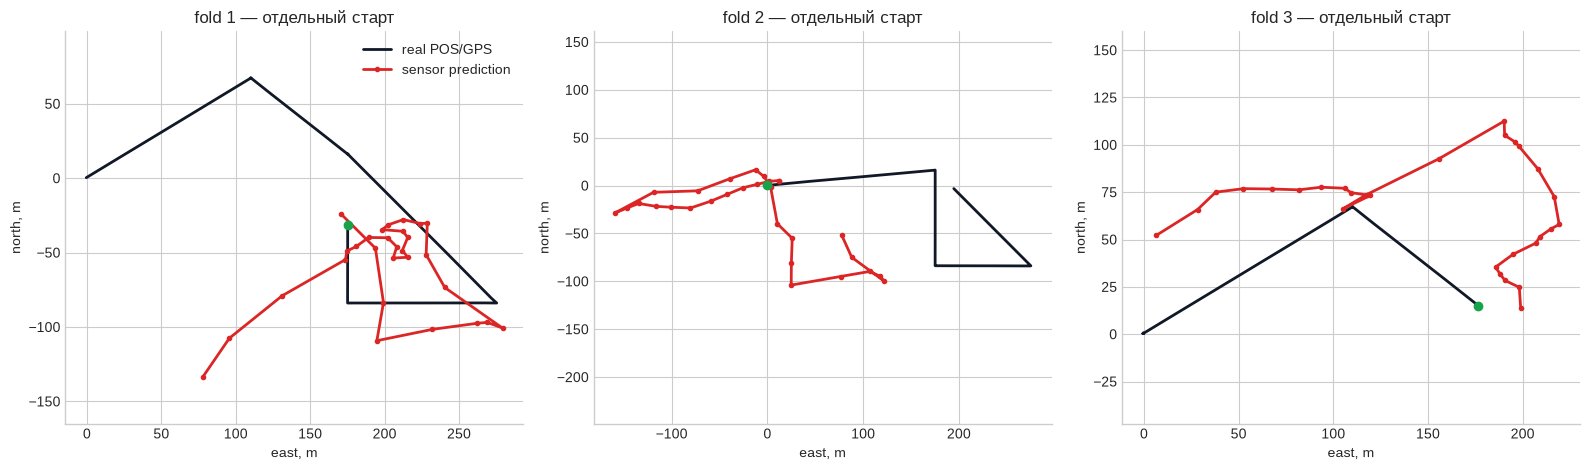

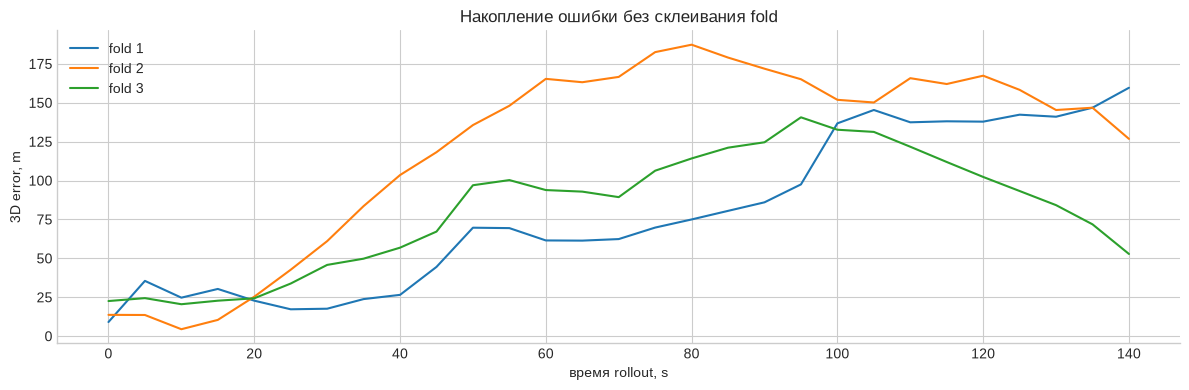

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for fold_id, ax in enumerate(axes, 1):
    r = rollout_df[rollout_df.fold == fold_id]
    ax.plot(r.true_e, r.true_n, color='#111827', lw=2, label='real POS/GPS')
    ax.plot(r.pred_e, r.pred_n, color='#dc2626', lw=2, marker='o', ms=3, label='sensor prediction')
    ax.scatter(r.true_e.iloc[0], r.true_n.iloc[0], color='#16a34a', zorder=3)
    ax.set(title=f'fold {fold_id} — отдельный старт', xlabel='east, m', ylabel='north, m')
    ax.axis('equal')
axes[0].legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(12,4))
for fold_id, r in rollout_df.groupby('fold'):
    ax.plot(np.arange(len(r))*5, r.err_3d, label=f'fold {fold_id}')
ax.set(xlabel='время rollout, s', ylabel='3D error, m', title='Накопление ошибки без склеивания fold')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Гипотеза о режимах полета и проверка утечки

Ошибка действительно меняется на hover/climb/descent. Но классифицировать режим по истинному будущему `POS`, как в первом prototype state-gated rollout, нельзя: это oracle с утечкой целевой переменной. Ниже oracle оставлен только как оценка потенциальной пользы гипотезы, а затем строится deployable-вариант по `BARO.CRt` и величине собственного предсказания.

,rows,mean,median
oracle_state,,,
climb,7,11.317,12.697
descent,18,11.358,12.314
hover,22,12.575,12.048
translate,40,16.281,13.060


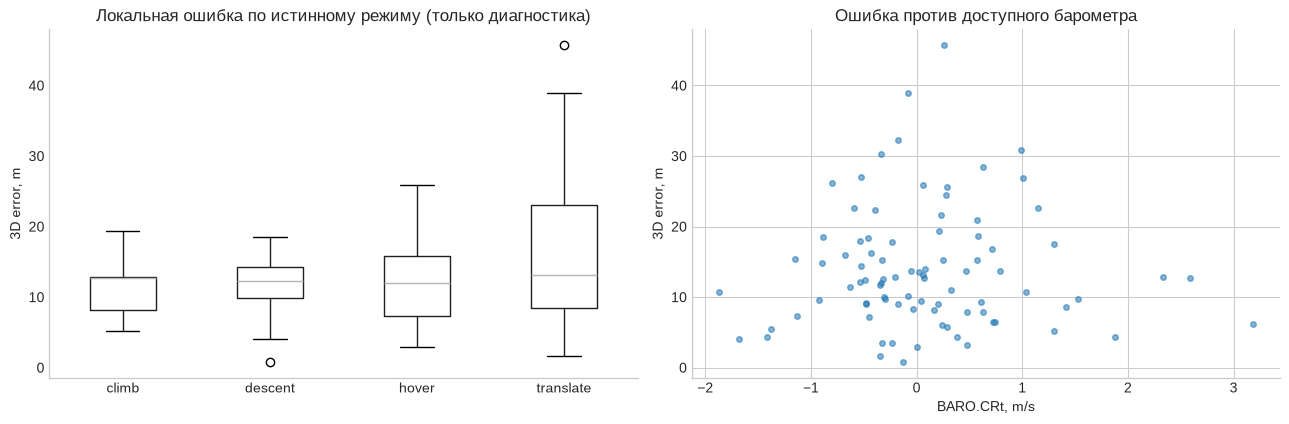

In [13]:
baro_time = baro.TimeUS.to_numpy(float)
baro_crt = baro.CRt.to_numpy(float)

def nearest_baro_crt(time_us):
    i = np.searchsorted(baro_time, time_us)
    i = np.clip(i, 1, len(baro_time)-1)
    if abs(baro_time[i-1]-time_us) < abs(baro_time[i]-time_us): i -= 1
    return baro_crt[i]

diagnostics = []
for p in predictions:
    for local_i, data_i in non_overlapping(p['fold']['test']):
        true_delta, pred_delta = ds['y'][data_i], p['test_pred'][local_i]
        dt = (ds['future_time'][data_i]-ds['time'][data_i])/1e6
        hspeed, vspeed = np.linalg.norm(true_delta[:2])/dt, true_delta[2]/dt
        if abs(vspeed)<.35 and hspeed<.6: oracle='hover'
        elif vspeed>=.35 and hspeed<.8: oracle='climb'
        elif vspeed<=-.35 and hspeed<.8: oracle='descent'
        else: oracle='translate'
        diagnostics.append({'fold':p['fold']['fold'], 'oracle_state':oracle, 'baro_CRt':nearest_baro_crt(ds['time'][data_i]),
                            'pred_xy_speed':np.linalg.norm(pred_delta[:2])/dt,
                            'local_error_3d':np.linalg.norm(pred_delta-true_delta)})
diag_df = pd.DataFrame(diagnostics)
display(diag_df.groupby('oracle_state').local_error_3d.agg(rows='size', mean='mean', median='median').round(3))

fig, ax = plt.subplots(1,2,figsize=(13,4.5))
diag_df.boxplot(column='local_error_3d', by='oracle_state', ax=ax[0], grid=False)
ax[0].set(title='Локальная ошибка по истинному режиму (только диагностика)', xlabel='', ylabel='3D error, m')
fig.suptitle('')
ax[1].scatter(diag_df.baro_CRt, diag_df.local_error_3d, s=16, alpha=.55)
ax[1].set(xlabel='BARO.CRt, m/s', ylabel='3D error, m', title='Ошибка против доступного барометра')
plt.tight_layout(); plt.show()

## 9. Sensor-only state gating

Доступное во время полета правило:

- `vertical`: `|BARO.CRt|` выше порога;
- `probable_hover`: барометр показывает почти постоянную высоту и сама модель предсказывает малую горизонтальную скорость;
- иначе `translate`.

Пороги и масштабы XY выбираются только на validation-блоке каждого fold перебором небольшой сетки, затем без изменений применяются к test. GPS/POS не участвует в классификации test-режима.

In [14]:
def make_sensor_gate(v_thr, hover_speed, vertical_scale, hover_scale):
    def gate(data_i, delta):
        dt = (ds['future_time'][data_i]-ds['time'][data_i])/1e6
        crt = nearest_baro_crt(ds['time'][data_i])
        pred_speed = np.linalg.norm(delta[:2])/dt
        if abs(crt) >= v_thr: return vertical_scale, 'vertical'
        if pred_speed < hover_speed: return hover_scale, 'probable_hover'
        return 1.0, 'translate'
    return gate

grid = [(vt, hs, vs, hsc) for vt in [.25,.5,.75,1.0] for hs in [.4,.8,1.2,2.0]
        for vs in [.25,.5,.75,1.0] for hsc in [.25,.5,.75,1.0]]
gated_rollouts, selected_rules = [], []
for p in predictions:
    f = p['fold']
    best = None
    for params in grid:
        r = rollout(f['val'], p['val_pred'], make_sensor_gate(*params))
        score = r.err_3d.mean()  # validation-only model selection
        if best is None or score < best[0]: best = (score, params)
    params = best[1]
    test_r = rollout(f['test'], p['test_pred'], make_sensor_gate(*params))
    test_r['fold'] = f['fold']; gated_rollouts.append(test_r)
    selected_rules.append({'fold':f['fold'], 'val_mean_error':best[0], 'v_threshold':params[0],
                           'hover_pred_speed':params[1], 'vertical_xy_scale':params[2], 'hover_xy_scale':params[3]})

gated_df = pd.concat(gated_rollouts, ignore_index=True)
display(pd.DataFrame(selected_rules).round(3))
comparison = []
for fold_id in range(1,4):
    base = rollout_df[rollout_df.fold==fold_id]; gated = gated_df[gated_df.fold==fold_id]
    comparison.append({'fold':fold_id, 'baseline mean':base.err_3d.mean(), 'gated mean':gated.err_3d.mean(),
                       'baseline final':base.err_3d.iloc[-1], 'gated final':gated.err_3d.iloc[-1],
                       'mean delta':gated.err_3d.mean()-base.err_3d.mean()})
display(pd.DataFrame(comparison).round(3))

,fold,val_mean_error,v_threshold,hover_pred_speed,vertical_xy_scale,hover_xy_scale
0,1,49.277,0.75,2.0,0.25,0.25
1,2,55.335,1.00,0.8,0.25,0.25
2,3,32.409,0.75,2.0,0.50,0.25


,fold,baseline mean,gated mean,baseline final,gated final,mean delta
0,1,78.312,93.721,159.646,183.922,15.409
1,2,121.245,103.667,126.784,99.939,-17.578
2,3,81.058,79.148,52.818,41.824,-1.910


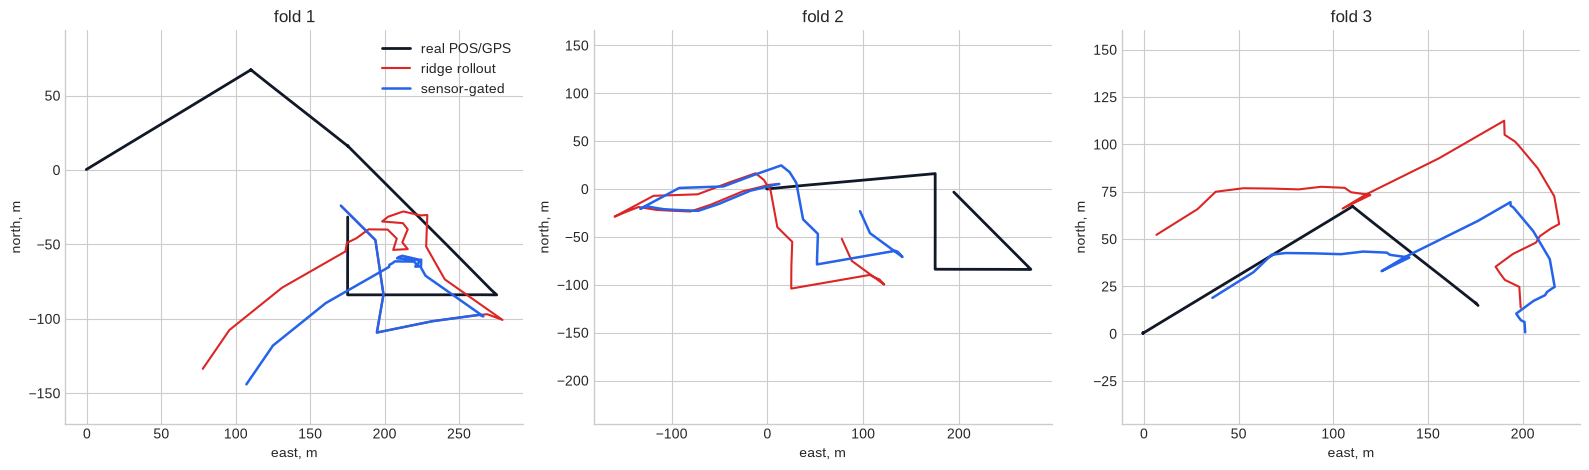

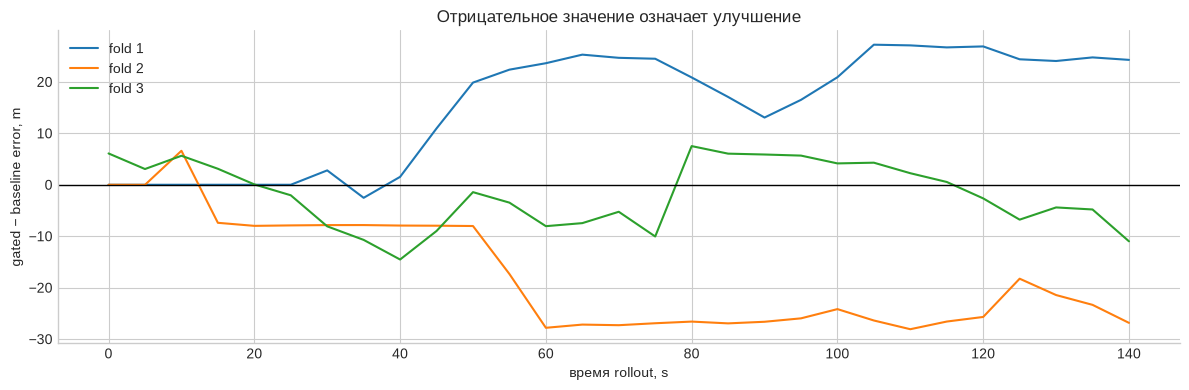

In [15]:
fig, axes = plt.subplots(1,3,figsize=(16,4.8))
for fold_id, ax in enumerate(axes,1):
    b=rollout_df[rollout_df.fold==fold_id]; g=gated_df[gated_df.fold==fold_id]
    ax.plot(b.true_e,b.true_n,color='#111827',lw=2,label='real POS/GPS')
    ax.plot(b.pred_e,b.pred_n,color='#dc2626',lw=1.5,label='ridge rollout')
    ax.plot(g.pred_e,g.pred_n,color='#2563eb',lw=1.8,label='sensor-gated')
    ax.set(title=f'fold {fold_id}',xlabel='east, m',ylabel='north, m'); ax.axis('equal')
axes[0].legend(); plt.tight_layout(); plt.show()

fig, ax=plt.subplots(figsize=(12,4))
for fold_id in range(1,4):
    b=rollout_df[rollout_df.fold==fold_id].reset_index(); g=gated_df[gated_df.fold==fold_id].reset_index()
    ax.plot(np.arange(len(b))*5, g.err_3d-b.err_3d, label=f'fold {fold_id}')
ax.axhline(0,color='black',lw=1)
ax.set(xlabel='время rollout, s',ylabel='gated − baseline error, m',title='Отрицательное значение означает улучшение')
ax.legend(); plt.tight_layout(); plt.show()

## 10. Итог и честная граница результата

Что подтверждено этим notebook:

1. Последовательность `IMU + ATT + BARO` несет сигнал о 5-секундном перемещении и в среднем улучшает local prediction относительно нулевого baseline.
2. Небольшая коррекция среднего residual, выбранная только на validation, снижает локальную ошибку, но rollout остается чувствителен к малому систематическому bias.
3. Реальные и предсказанные траектории следует показывать отдельно для трех fold: это три тестовых отрезка одного полета с разными стартами.
4. Связь ошибки с режимами полета существует. Oracle-gating по будущему POS нельзя считать навигационным алгоритмом; sensor-only gating выше является корректной проверкой и должен оцениваться по таблице, а не приниматься заранее.

На текущем логе sensor-only gating не является устойчивым улучшением: он помогает на fold 2 и 3, но ухудшает fold 1. Поэтому итоговым baseline остается `sequence_ridge + validation-tuned bias`, а gating сохраняется как проверенная, но пока не принятая гипотеза.

Проект не уперся в математический тупик, но дальнейшая подгонка на этом же логе даст все менее надежные выводы. Главный следующий шаг — получить несколько независимых DataFlash-полетов и делать split целиком по полетам. После этого разумно сравнить ridge с моделью, которая прямо оптимизирует накопленную rollout-ошибку, и добавить optical flow только для логов, где он действительно записан. До появления независимых полетов текущую модель следует считать исследовательским внутриполетным baseline, а не готовой инерциальной навигацией.